# 05 — Results

Every table in this notebook is read from `data/processed/`, not recomputed. Those files
are produced by:

```bash
python scripts/run_experiment.py
```

Delete `data/processed/` entirely, run that command, and every number below returns
byte-identical. This notebook builds the figures the README embeds.

In [1]:
import sys; sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config as cfg
from src.plots import set_style, save_fig

set_style()
pd.set_option("display.width", 200)

read = lambda name, **kw: pd.read_csv(cfg.DATA_PROCESSED / f"results_{name}.csv", **kw)

final = read("final", index_col=0)
single = read("single_feature")
ci = read("bootstrap_ci")
cost = read("cost_thresholds")
baseline_tbl = read("baseline")
vs_multi = read("single_vs_multi", index_col=0)

BASELINE = baseline_tbl.loc[baseline_tbl.split == "train", "majority_class_baseline"].iloc[0]
print(f"majority-class baseline: {BASELINE:.4f}")

majority-class baseline: 0.6867


## The headline

One feature, one held-out test set of 1,500 customers, scored once.

In [2]:
headline = final.loc["driving_experience @ 0.5"]
ceiling = final.loc["all features @ 0.5 (ceiling)"]

print(f"  feature              driving_experience")
print(f"  test accuracy        {headline.accuracy:.4f}")
print(f"  baseline             {headline.baseline:.4f}   (predict 'no claim' for everyone)")
print(f"  lift                 {headline.lift_over_baseline:+.4f}")
print(f"  ROC-AUC              {headline.roc_auc:.4f}")
print()
print(f"  reference reported   0.7771   (in-sample, all 10,000 rows, no baseline stated)")
print(f"  15-feature ceiling   {ceiling.accuracy:.4f}   (lift {ceiling.lift_over_baseline:+.4f})")

  feature              driving_experience
  test accuracy        0.7647
  baseline             0.6867   (predict 'no claim' for everyone)
  lift                 +0.0780
  ROC-AUC              0.7938

  reference reported   0.7771   (in-sample, all 10,000 rows, no baseline stated)
  15-feature ceiling   0.8233   (lift +0.1366)


In [3]:
final.round(4)

,accuracy,baseline,lift_over_baseline,roc_auc,precision,recall,expected_cost_5to1
model,,,,,,,
driving_experience @ 0.5,0.7647,0.6867,0.0780,0.7938,0.6073,0.7043,0.6060
age @ 0.5 (runner-up),0.7747,0.6867,0.0880,0.7542,0.7075,0.4787,0.8787
driving_experience @ 0.05 (cost-optimal),0.5993,0.6867,-0.0874,0.7938,0.4357,0.9447,0.4700
all features @ 0.5 (ceiling),0.8233,0.6867,0.1366,0.8778,0.7243,0.7043,0.5473
all features @ 0.16 (cost-optimal),0.7220,0.6867,0.0353,0.8778,0.5331,0.9085,0.3927


## Figure 1 — what the accuracy number actually contains

The reference reports 77.71% as its result. The bar below decomposes what a number like
that is made of: most of it is the base rate, available for free by predicting "no claim"
for everyone.

findfont: Failed to find font weight semibold, now using 700.


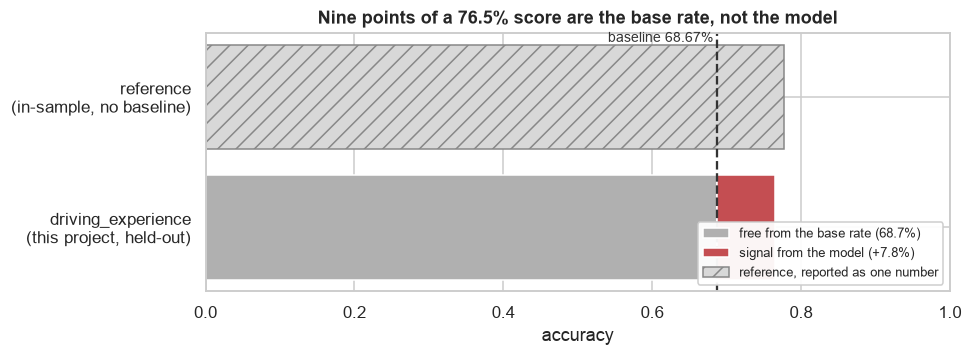

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.4))

acc = headline.accuracy
ax.barh(["driving_experience\n(this project, held-out)"], [BASELINE],
        color="#B0B0B0", label=f"free from the base rate ({BASELINE:.1%})")
ax.barh(["driving_experience\n(this project, held-out)"], [acc - BASELINE], left=[BASELINE],
        color="#C44E52", label=f"signal from the model (+{acc - BASELINE:.1%})")
ax.barh(["reference\n(in-sample, no baseline)"], [0.7771], color="#D8D8D8",
        edgecolor="#888", hatch="//", label="reference, reported as one number")

ax.axvline(BASELINE, color="#333", ls="--", lw=1.5)
ax.text(BASELINE - 0.005, 1.42, "baseline 68.67%", ha="right", fontsize=9, color="#333")
ax.set_xlim(0, 1.0)
ax.set_xlabel("accuracy")
ax.set_title("Nine points of a 76.5% score are the base rate, not the model", fontsize=11.5)
ax.legend(fontsize=8.5, loc="lower right", framealpha=0.95)
fig.tight_layout()
save_fig(fig, "headline_accuracy_decomposition")
plt.show()

## Figure 2 — the metric decides the answer

Every feature, ranked two ways. Under accuracy, nine of sixteen features are worthless.
Under expected cost at a 5:1 false-negative-to-false-positive ratio, two of those nine
are among the best available.

findfont: Failed to find font weight semibold, now using 700.


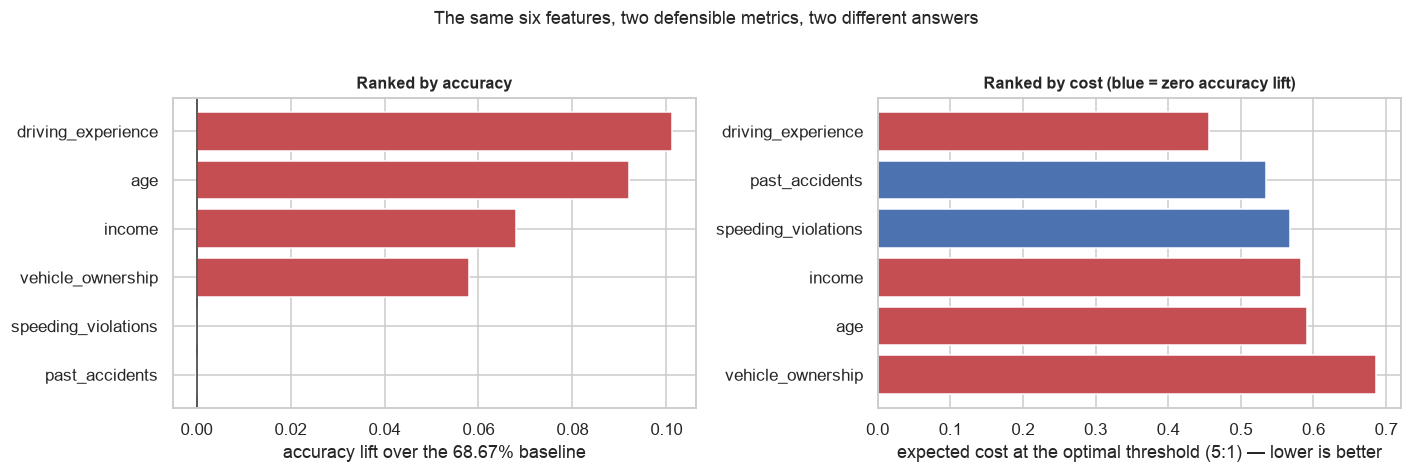

In [5]:
dummy = single[single.scheme == "dummy"].set_index("feature")
merged = cost[~cost.feature.str.startswith("[")].set_index("feature").join(
    dummy[["lift_over_baseline", "roc_auc"]])

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

d1 = merged.sort_values("lift_over_baseline")
axes[0].barh(d1.index, d1.lift_over_baseline,
             color=["#C44E52" if v > 0 else "#B0B0B0" for v in d1.lift_over_baseline])
axes[0].axvline(0, color="#333", lw=1)
axes[0].set_xlabel("accuracy lift over the 68.67% baseline")
axes[0].set_title("Ranked by accuracy", fontsize=10.5)

d2 = merged.sort_values("cost_at_optimum", ascending=False)
highlight = {"speeding_violations", "past_accidents"}
axes[1].barh(d2.index, d2.cost_at_optimum,
             color=["#4C72B0" if f in highlight else "#C44E52" for f in d2.index])
axes[1].set_xlabel("expected cost at the optimal threshold (5:1) — lower is better")
axes[1].set_title("Ranked by cost (blue = zero accuracy lift)", fontsize=10.5)

fig.suptitle("The same six features, two defensible metrics, two different answers",
             y=1.02, fontsize=12)
fig.tight_layout()
save_fig(fig, "metric_changes_the_answer")
plt.show()

In [6]:
merged[["lift_over_baseline", "roc_auc", "optimal_threshold",
        "cost_at_optimum", "cost_at_0.5"]].sort_values("cost_at_optimum").round(4)

,lift_over_baseline,roc_auc,optimal_threshold,cost_at_optimum,cost_at_0.5
feature,,,,,
driving_experience,0.1013,0.8127,0.05,0.4567,0.5827
past_accidents,-0.0000,0.7258,0.26,0.5340,1.5667
speeding_violations,-0.0000,0.7318,0.32,0.5673,1.5667
income,0.0680,0.7586,0.14,0.5827,1.0107
age,0.0920,0.7676,0.16,0.5913,0.9040
vehicle_ownership,0.0580,0.6972,0.02,0.6867,0.7940


## Figure 3 — the winner's margin is not real

`driving_experience` beat `age` by 0.93 points on validation. The bootstrap interval for
that gap spans zero.

findfont: Failed to find font weight semibold, now using 700.


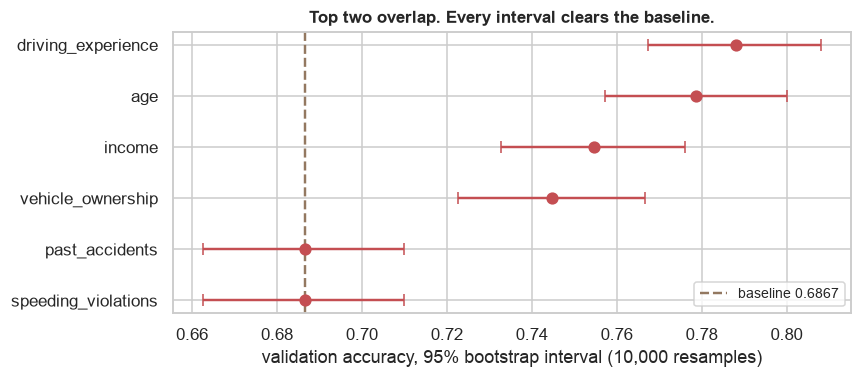

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.6))
d = ci.sort_values("accuracy")
ax.errorbar(d.accuracy, d.feature,
            xerr=[d.accuracy - d.ci_low, d.ci_high - d.accuracy],
            fmt="o", color="#C44E52", capsize=4, markersize=7, lw=1.6)
ax.axvline(BASELINE, color="#937860", ls="--", lw=1.6, label=f"baseline {BASELINE:.4f}")
ax.set_xlabel("validation accuracy, 95% bootstrap interval (10,000 resamples)")
ax.set_title("Top two overlap. Every interval clears the baseline.", fontsize=11)
ax.legend(fontsize=9)
fig.tight_layout()
save_fig(fig, "results_bootstrap_ci")
plt.show()

## What the single-feature constraint costs

The client asked for one feature because they cannot deploy anything larger. Here is the
price of that constraint, measured rather than asserted.

In [8]:
vs_multi.round(4)

,accuracy,lift_over_baseline,roc_auc,precision,recall,brier
single feature (driving_experience),0.788,0.1013,0.8127,0.6490,0.7043,0.1520
all 15 features,0.848,0.1613,0.9045,0.7881,0.7043,0.1107


In [9]:
gap_acc = final.loc["all features @ 0.5 (ceiling)", "accuracy"] - final.loc["driving_experience @ 0.5", "accuracy"]
gap_auc = final.loc["all features @ 0.5 (ceiling)", "roc_auc"] - final.loc["driving_experience @ 0.5", "roc_auc"]
c_single = final.loc["driving_experience @ 0.05 (cost-optimal)", "expected_cost_5to1"]
c_multi = final.loc["all features @ 0.16 (cost-optimal)", "expected_cost_5to1"]

print("On the test set, the one-feature constraint costs:")
print(f"  {gap_acc:.4f} accuracy")
print(f"  {gap_auc:.4f} ROC-AUC")
print(f"  {c_single / c_multi - 1:.1%} higher expected cost at 5:1")

On the test set, the one-feature constraint costs:
  0.0587 accuracy
  0.0839 ROC-AUC
  19.7% higher expected cost at 5:1


## Robustness: does the headline depend on the artifact?

Postal code 21217 contains 120 customers who all filed a claim — a generation artifact,
not a fact about drivers. It is excluded from the recommendation, but it is still sitting
in the training data for every other feature's model.

Stating that as a limitation is weaker than measuring it. Removing those 120 rows and
re-running the entire pipeline from the split onward answers the question directly.

In [10]:
sens = read("sensitivity")
wide = sens.pivot(index="feature", columns="dataset",
                  values=["accuracy", "lift_over_baseline", "roc_auc"])
wide.columns = [f"{m}__{d}" for m, d in wide.columns]
wide["lift_change"] = wide["lift_over_baseline__artifact removed"] - wide["lift_over_baseline__full dataset"]
wide["auc_change"] = wide["roc_auc__artifact removed"] - wide["roc_auc__full dataset"]
wide[["lift_over_baseline__full dataset", "lift_over_baseline__artifact removed",
      "lift_change", "roc_auc__full dataset", "roc_auc__artifact removed", "auc_change"]].round(4)

,lift_over_baseline__full dataset,lift_over_baseline__artifact removed,lift_change,roc_auc__full dataset,roc_auc__artifact removed,auc_change
feature,,,,,,
age,0.0880,0.0796,-0.0084,0.7542,0.7721,0.0179
driving_experience,0.0780,0.0762,-0.0018,0.7938,0.8111,0.0172
income,0.0526,0.0580,0.0054,0.7316,0.7572,0.0256
vehicle_ownership,0.0326,0.0458,0.0132,0.6707,0.7025,0.0318


**The headline survives.** `driving_experience` keeps a lift of +0.0762 against +0.0780,
a change of −0.0018 — well inside the bootstrap interval on the original estimate. Its
ROC-AUC actually *improves*, from 0.794 to 0.811, which is what you would expect when a
degenerate group that no feature can rank is taken out of the data.

The artifact was not propping up the result. That is now a measured statement rather than
a hopeful one, and `tests/test_reproducibility.py` asserts it so it cannot quietly stop
being true.

Note that the baseline rises from 0.6867 to 0.6951 once the 120 all-claim rows are gone —
removing them lowers the claim rate. Comparing raw accuracies across the two columns would
be a mistake; the lift columns are the ones that mean the same thing in both.

## The recommendation, and the honest caveat on it

The results table above reports the runner-up on test as well as the winner, and the
comparison deserves stating plainly.

In [11]:
final.loc[["driving_experience @ 0.5", "age @ 0.5 (runner-up)"],
          ["accuracy", "lift_over_baseline", "roc_auc"]].round(4)

,accuracy,lift_over_baseline,roc_auc
model,,,
driving_experience @ 0.5,0.7647,0.078,0.7938
age @ 0.5 (runner-up),0.7747,0.088,0.7542


**On the test set, `age` scores higher than `driving_experience` — 0.7747 against
0.7647.** The order reverses from validation, where `driving_experience` led 0.7880 to
0.7787.

This is not a contradiction of the earlier finding. It *is* the earlier finding. The
bootstrap put the 95% interval for the gap at [−0.010, +0.029] and concluded the two were
statistically indistinguishable; a rank reversal on a fresh 1,500-customer sample is
precisely what "indistinguishable" looks like when you go and draw one.

`driving_experience` remains the recommendation, for a reason that does not depend on the
accuracy coin-flip: its ROC-AUC is 0.794 against 0.754, so it ranks customers by risk
appreciably better. For an insurer that eventually wants to price rather than merely
flag, that is the property worth having.

But the defensible sentence is the tie, not the win. Anyone reporting one of these two
features as *the* answer, on either split, is reading noise.

## Summary of every finding

| # | Finding | Evidence |
|---|---|---|
| 1 | The reference's 77.71% is 9 points of signal on a 68.67% floor it never states | class balance, 31.33% positive |
| 2 | Held-out accuracy is 76.47%, lift +7.80, CI [+5.66, +9.93] | test set, scored once |
| 3 | The winner is statistically tied with `age` | bootstrap gap CI [−0.010, +0.029] |
| 4 | Accuracy is blind to nine of sixteen features | zero predicted-positive rate |
| 5 | Two of those nine are top-3 under cost | `past_accidents`, `speeding_violations` |
| 6 | The 0.5 threshold is never optimal | 0.25 at 1:1, 0.05 at 5:1 |
| 7 | The baseline itself flips under asymmetric cost | always-claim 0.687 vs always-no-claim 1.567 |
| 8 | Missingness carries no signal | p = 0.67, 0.091; nothing survives Bonferroni |
| 9 | The imputation leak is worth one row in 1,500 | leaky vs honest refit |
| 10 | Encoding by dtype compared 4-parameter and 2-parameter models | `n_parameters` by scheme |
| 11 | `postal_code` perfectly separates 120 customers | 100% claim rate, coefficient 22.3 |
| 12 | The one-feature constraint costs ~6 accuracy points | 15-feature ceiling |
| 13 | The headline does not depend on the artifact | lift −0.0018 when 21217 removed, AUC +0.017 |
| 14 | On test, the runner-up scores *higher* | `age` 0.7747 vs `driving_experience` 0.7647 |